In [1]:
# Run from the repo root regardless of where Jupyter started this kernel
# (Jupyter normally sets cwd to this notebook's own folder, i.e. notebooks/).
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print(f"Working directory: {Path.cwd()}")


Working directory: /Users/seyeong/hw1


# KOSPI Next-Day Prediction: How Much Can Price and Volume Tell Us?

Predicting the next trading day's KOSPI close, worked through four stages. The
goal is less a high R² than an honest answer to *whether the models learn anything*.

| Part | Question | Takeaway |
|---|---|---|
| 1 | How far do OHLCV lags go? | Linear models roughly match a "tomorrow = today" baseline |
| 2 | Do technical indicators help? | R² changes by about +0.001 |
| 3 | Do tuning, ensembling, and more features help? | No; adds redundant features, and no model beats the baseline |
| 4 | What about predicting *returns*? | No model beats a zero forecast or "always up" |

**Method notes.** Data: 2019–2022 train, 2023 test. Models are chosen by
`TimeSeriesSplit` CV on training data only; the test set is used for reporting.
All parts share identical train/test rows, so the numbers are comparable.


In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from xgboost import XGBRegressor
import joblib

warnings.filterwarnings('ignore')


## Read training and test datasets


In [3]:
from src.data import read_data


In [4]:
df_train = read_data('data/kospi_train.csv')
df_test = read_data('data/kospi_test.csv')

len(df_train), len(df_test)


(986, 244)

In [5]:
# the training dataset has daily KOSPI index from 2019 to 2022
df_train


,Date,Open,Low,High,Close,Volume
0,2019-01-02,2050.550049,2004.270020,2053.449951,2010.000000,326400
1,2019-01-03,2011.810059,1991.650024,2014.719971,1993.699951,428000
2,2019-01-04,1992.400024,1984.530029,2011.560059,2010.250000,409000
3,2019-01-07,2034.239990,2030.900024,2048.060059,2037.099976,440200
4,2019-01-08,2038.680054,2023.589966,2042.699951,2025.270020,397800
...,...,...,...,...,...,...
981,2022-12-23,2325.860107,2311.899902,2333.080078,2313.689941,367000
982,2022-12-26,2312.540039,2304.199951,2321.919922,2317.139893,427600
983,2022-12-27,2327.520020,2321.479980,2335.989990,2332.790039,448300
984,2022-12-28,2296.449951,2276.899902,2296.449951,2280.449951,405700


In [6]:
# the test dataset has daily KOSPI index in 2023
df_test


,Date,Open,Low,High,Close,Volume
0,2023-01-02,2249.949951,2222.370117,2259.879883,2225.669922,346100
1,2023-01-03,2230.979980,2180.669922,2230.979980,2218.679932,410000
2,2023-01-04,2205.979980,2198.820068,2260.060059,2255.979980,412700
3,2023-01-05,2268.199951,2252.969971,2281.389893,2264.649902,430800
4,2023-01-06,2253.399902,2253.270020,2300.620117,2289.969971,398300
...,...,...,...,...,...,...
239,2023-12-21,2598.370117,2587.159912,2610.810059,2600.020020,578300
240,2023-12-22,2617.719971,2599.510010,2621.370117,2599.510010,466000
241,2023-12-26,2609.439941,2594.649902,2612.139893,2602.590088,439500
242,2023-12-27,2599.350098,2590.080078,2613.500000,2613.500000,349700


## Part 1. Predict KOSPI of the next day.
### Train regression models to predict the next day's `close` using `Open`, `Low`, `High`, `Close`, `Volume` of previous days as predictors using *only* df_train. Cross-validate to select the best model. Evaluate the accuracy of your model using `df_test`.


In [7]:
print(f"Train size: {len(df_train)}, test size: {len(df_test)}")


Train size: 986, test size: 244


In [8]:
# Inspect the data
print("\nTrain data sample:")
print(df_train.head())

# Descriptive statistics
print("\nTrain data statistics:")
print(df_train.describe())

# Missing values
print("\nMissing values:")
print(df_train.isnull().sum())



Train data sample:
        Date         Open          Low         High        Close  Volume
0 2019-01-02  2050.550049  2004.270020  2053.449951  2010.000000  326400
1 2019-01-03  2011.810059  1991.650024  2014.719971  1993.699951  428000
2 2019-01-04  1992.400024  1984.530029  2011.560059  2010.250000  409000
3 2019-01-07  2034.239990  2030.900024  2048.060059  2037.099976  440200
4 2019-01-08  2038.680054  2023.589966  2042.699951  2025.270020  397800

Train data statistics:
                                Date         Open          Low         High  \
count                            986   986.000000   986.000000   986.000000   
mean   2020-12-30 22:44:03.407708160  2491.245019  2473.949038  2505.511379   
min              2019-01-02 00:00:00  1474.449951  1439.430054  1516.750000   
25%              2020-01-02 06:00:00  2141.460022  2125.494995  2153.652527   
50%              2020-12-29 12:00:00  2373.609985  2355.854980  2387.719971   
75%              2021-12-27 18:00:00  2935.3

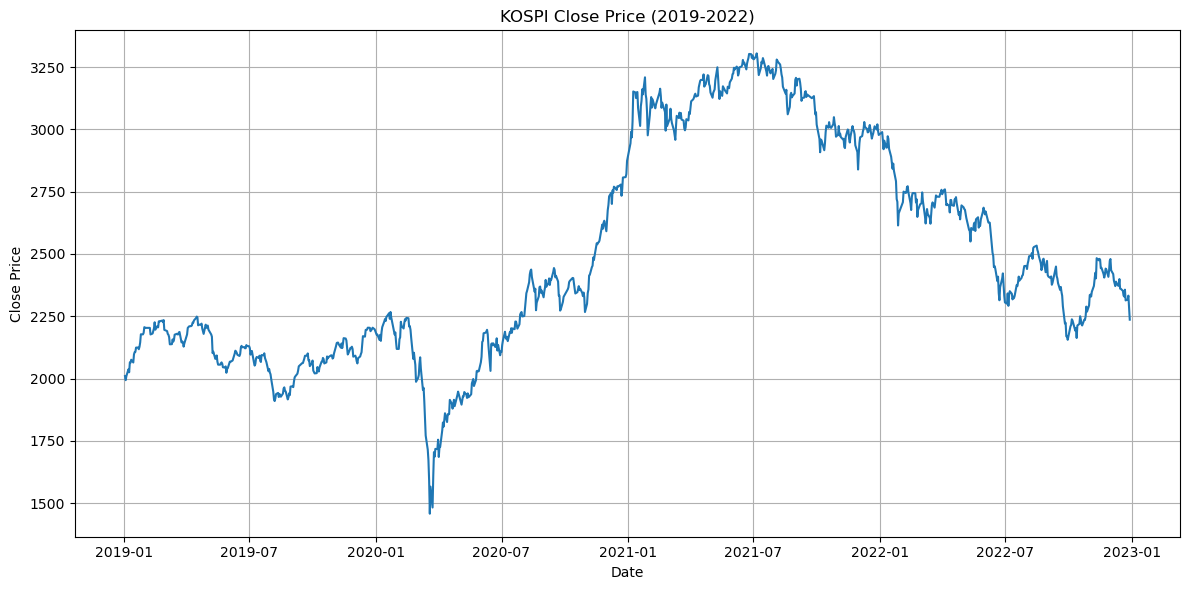

In [9]:
# Plot the closing price
plt.figure(figsize=(12, 6))
plt.plot(df_train['Date'], df_train['Close'])
plt.title('KOSPI Close Price (2019-2022)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/kospi_close_price.png')
plt.show()


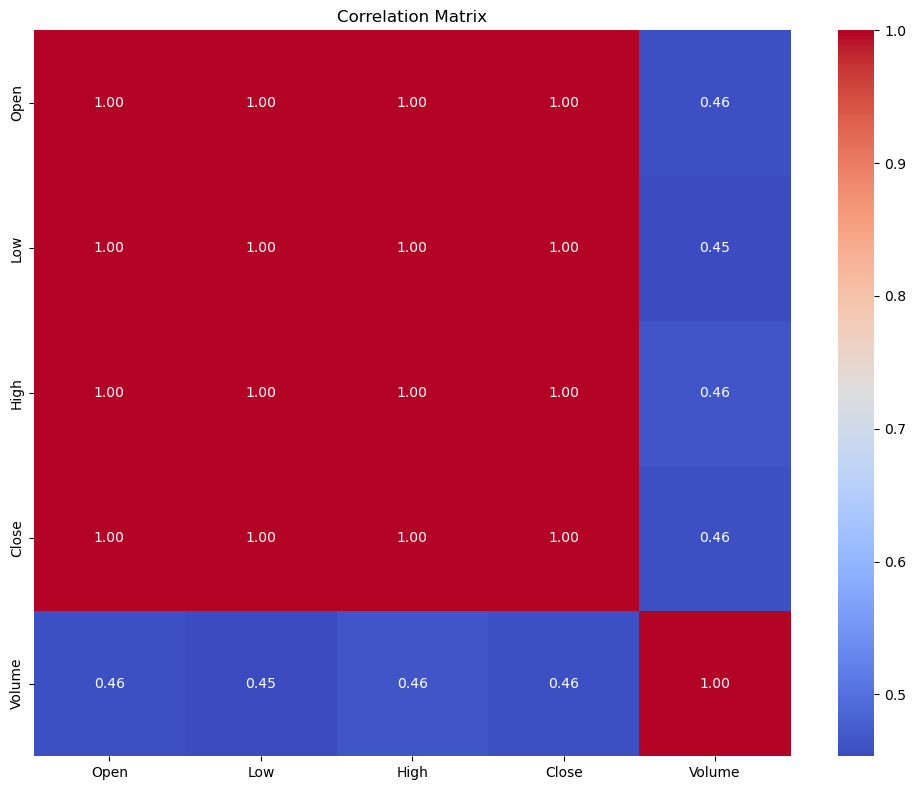

In [10]:
# Correlation analysis
plt.figure(figsize=(10, 8))
correlation = df_train[['Open', 'Low', 'High', 'Close', 'Volume']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('figures/correlation_matrix.png')
plt.show()


In [11]:
# Feature construction and the train/test split live in src/features.py (shared by Parts 1-4, unit-tested)
from src.features import (
    LAGS, PART1_FEATURES, PART2_FEATURES, PART3_FEATURES, PART4_FEATURES,
    build_full_frame, add_lag_features, split_features,
)


In [12]:
from src.features import prepare_part1_features


In [13]:
from src.evaluation import scale_features


In [14]:
from src.evaluation import evaluate_model


In [15]:
from src.evaluation import time_series_cv


In [16]:
# Model set and CV-based selection: src/models.py
from src.models import get_base_models, train_and_evaluate_models


In [17]:
# Part 1: train and evaluate the base models
print("\n=== Part 1: predict the KOSPI close from current and past OHLCV ===")
X_train, y_train, X_test, y_test, train_features, test_features = prepare_part1_features(df_train, df_test)

print("\nFeatures used:")
print(X_train.columns.tolist())



=== Part 1: predict the KOSPI close from current and past OHLCV ===

Features used:
['Open_lag_0', 'High_lag_0', 'Low_lag_0', 'Close_lag_0', 'Volume_lag_0', 'Open_lag_1', 'High_lag_1', 'Low_lag_1', 'Close_lag_1', 'Volume_lag_1', 'Open_lag_2', 'High_lag_2', 'Low_lag_2', 'Close_lag_2', 'Volume_lag_2', 'Open_lag_3', 'High_lag_3', 'Low_lag_3', 'Close_lag_3', 'Volume_lag_3', 'Open_lag_5', 'High_lag_5', 'Low_lag_5', 'Close_lag_5', 'Volume_lag_5']


In [18]:
# Scaling
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)


In [19]:
# Train and evaluate
results_part1, (best_model_name, best_model) = train_and_evaluate_models(X_train_scaled, y_train, X_test_scaled, y_test)

# Selected model
print(f"\nSelected by CV: {best_model_name}")



Training Linear Regression...
CV MSE: 1220.93
Linear Regression performance:
MSE: 580.30
RMSE: 24.09
MAE: 18.44
R^2: 0.9235

Training Ridge Regression...
CV MSE: 1463.18
Ridge Regression performance:
MSE: 581.64
RMSE: 24.12
MAE: 18.44
R^2: 0.9233

Training Lasso Regression...
CV MSE: 1199.91
Lasso Regression performance:
MSE: 599.59
RMSE: 24.49
MAE: 18.60
R^2: 0.9209

Training Elastic Net...
CV MSE: 2721.25
Elastic Net performance:
MSE: 919.84
RMSE: 30.33
MAE: 23.45
R^2: 0.8787

Training Random Forest...


CV MSE: 48023.69


Random Forest performance:
MSE: 752.43
RMSE: 27.43
MAE: 20.87
R^2: 0.9008

Training Gradient Boosting...


CV MSE: 48375.63


Gradient Boosting performance:
MSE: 690.13
RMSE: 26.27
MAE: 20.38
R^2: 0.9090

Training XGBoost...


CV MSE: 56442.78
XGBoost performance:
MSE: 1115.95
RMSE: 33.41
MAE: 26.65
R^2: 0.8529

Selected by CV: Lasso Regression


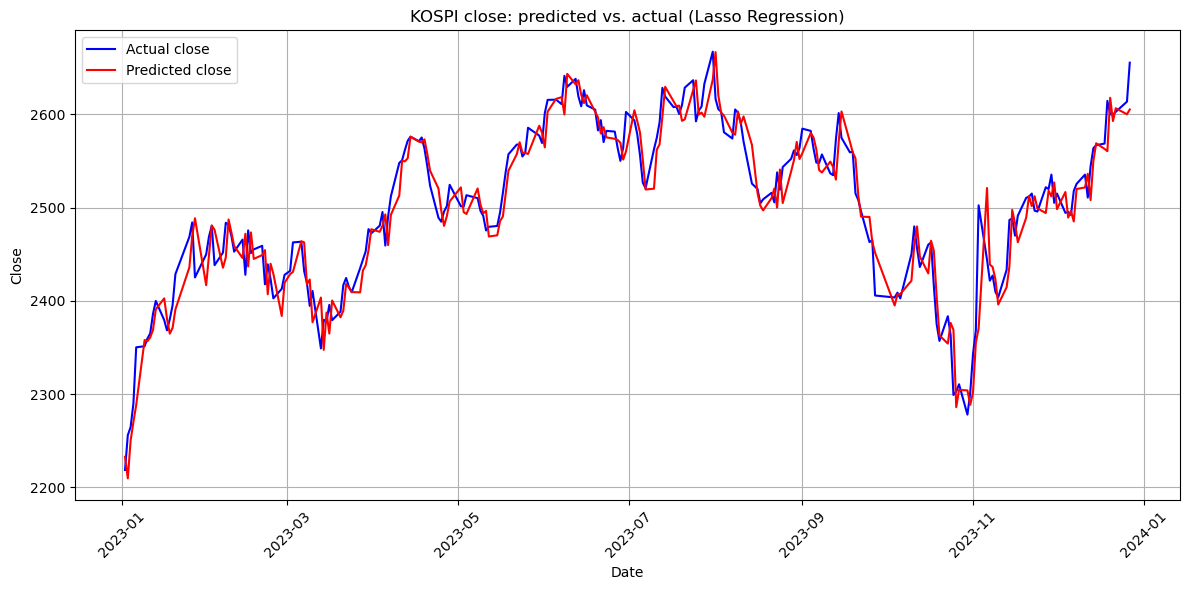

In [20]:
# Predicted vs. actual
y_pred = best_model.predict(X_test_scaled)

dates = test_features['Date']
y_test_aligned = y_test.values
y_pred_aligned = y_pred

plt.figure(figsize=(12, 6))
plt.plot(dates, y_test_aligned, label='Actual close', color='blue')
plt.plot(dates, y_pred_aligned, label='Predicted close', color='red')
plt.title(f'KOSPI close: predicted vs. actual ({best_model_name})')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/part1_model_prediction.png')
plt.show()


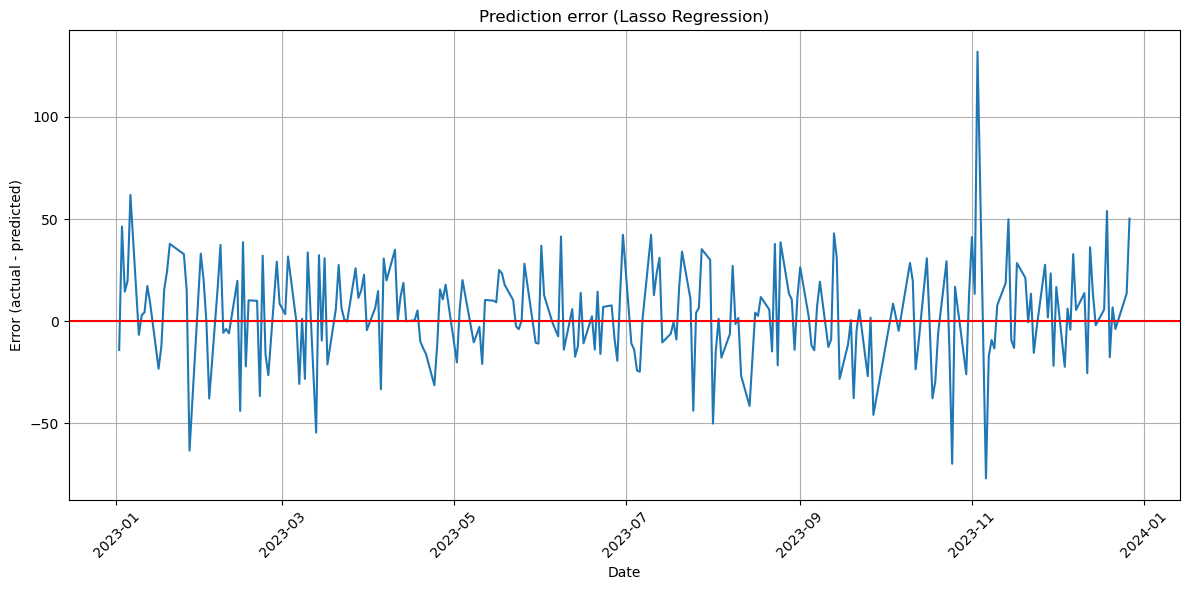

In [21]:
# Prediction errors
errors = y_test_aligned - y_pred_aligned

plt.figure(figsize=(12, 6))
plt.plot(dates, errors)
plt.axhline(y=0, color='r', linestyle='-')
plt.title(f'Prediction error ({best_model_name})')
plt.xlabel('Date')
plt.ylabel('Error (actual - predicted)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/part1_prediction_errors.png')
plt.show()


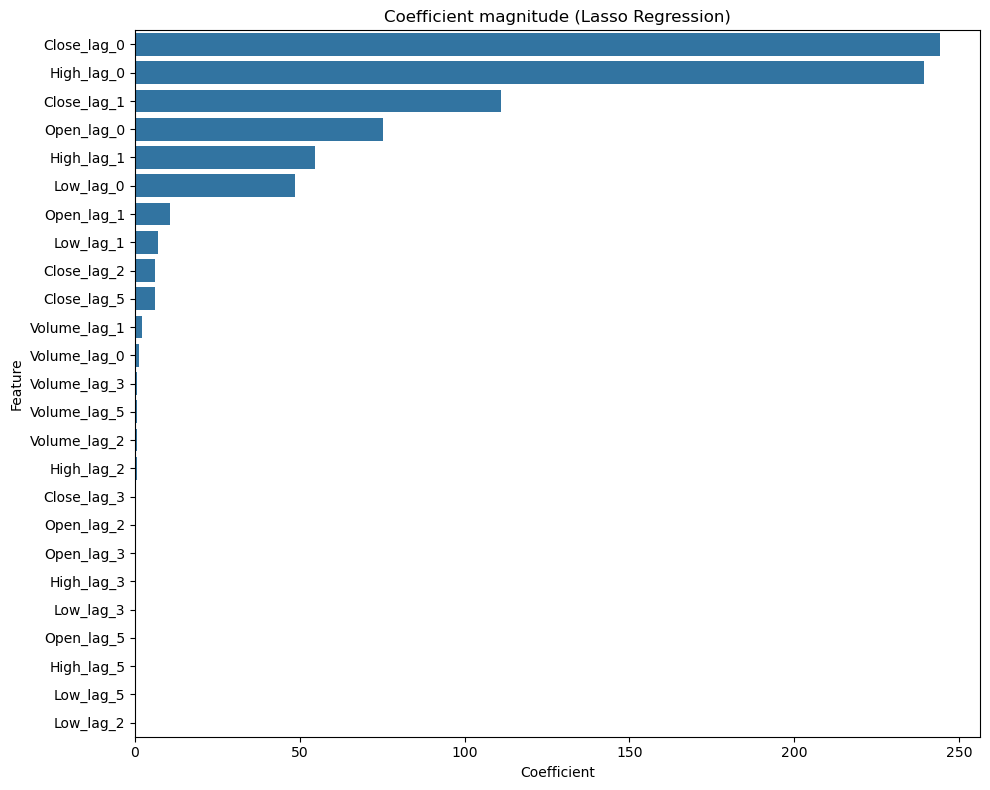


Coefficients:
         Feature  Coefficient
3    Close_lag_0   244.184518
1     High_lag_0   239.321651
8    Close_lag_1   110.913600
0     Open_lag_0    75.194481
6     High_lag_1    54.517945
2      Low_lag_0    48.603695
5     Open_lag_1    10.583083
7      Low_lag_1     7.097366
13   Close_lag_2     5.945266
23   Close_lag_5     5.927913
9   Volume_lag_1     2.169916
4   Volume_lag_0     1.073383
19  Volume_lag_3     0.699263
24  Volume_lag_5     0.668745
14  Volume_lag_2     0.638455
11    High_lag_2     0.511007
18   Close_lag_3     0.083037
10    Open_lag_2     0.006931
15    Open_lag_3     0.000000
16    High_lag_3     0.000000
17     Low_lag_3     0.000000
20    Open_lag_5     0.000000
21    High_lag_5     0.000000
22     Low_lag_5     0.000000
12     Low_lag_2     0.000000


In [22]:
# Coefficients or feature importances
if hasattr(best_model, 'feature_importances_'):  # tree-based model
    feature_importances = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importances)
    plt.title(f'Feature importance ({best_model_name})')
    plt.tight_layout()
    plt.savefig('figures/part1_feature_importance.png')
    plt.show()

    print("\nFeature importances:")
    print(feature_importances)

elif hasattr(best_model, 'coef_'):  # linear model
    # Use the absolute coefficient as importance
    coefficients = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': np.abs(best_model.coef_)  # absolute value
    }).sort_values('Coefficient', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Coefficient', y='Feature', data=coefficients)
    plt.title(f'Coefficient magnitude ({best_model_name})')
    plt.tight_layout()
    plt.savefig('figures/part1_feature_coefficients.png')
    plt.show()

    print("\nCoefficients:")
    print(coefficients)


In [23]:
# Save the model
joblib.dump(best_model, 'models/kospi_part1_model.pkl')
joblib.dump(scaler, 'models/kospi_part1_scaler.pkl')
print(f"\nSaved '{best_model_name}' (selected by CV): 'models/kospi_part1_model.pkl'")



Saved 'Lasso Regression' (selected by CV): 'models/kospi_part1_model.pkl'


### Part 1 takeaway

The CV-selected model is Lasso (test R² 0.9209, RMSE 24.49). Including the current
day's OHLCV (lag 0) matters: it is the same information the "tomorrow = today"
baseline uses (RMSE 24.09, computed in Part 3), and with it plain linear models land
right on top of that baseline. Price *level* is close to a random walk, so a high R²
here says little on its own.


## Part 2. Use more predictors to improve your model.

### Extend the regression model by adding some extra features of your choice. You can use any statistics publicly available.


In [24]:
from src.features import create_technical_features


In [25]:
from src.features import PART2_EXTRA_FEATURES, prepare_part2_features


In [26]:
def visualize_prediction_results(test_features, y_test, model, X_test_scaled, model_name, filename):
    y_pred = model.predict(X_test_scaled)

    dates = test_features['Date']
    y_test_aligned = y_test.values
    y_pred_aligned = y_pred

    plt.figure(figsize=(12, 6))
    plt.plot(dates, y_test_aligned, label='Actual close', color='blue')
    plt.plot(dates, y_pred_aligned, label='Predicted close', color='red')
    plt.title(f'KOSPI close: predicted vs. actual ({model_name})')
    plt.xlabel('Date')
    plt.ylabel('Close')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

    return y_test_aligned, y_pred_aligned, dates


def visualize_prediction_errors(y_test_aligned, y_pred_aligned, dates, model_name, filename):
    errors = y_test_aligned - y_pred_aligned

    plt.figure(figsize=(12, 6))
    plt.plot(dates, errors)
    plt.axhline(y=0, color='r', linestyle='-')
    plt.title(f'Prediction error ({model_name})')
    plt.xlabel('Date')
    plt.ylabel('Error (actual - predicted)')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

    return errors


def visualize_predictions(test_features, y_test, model, X_test_scaled, model_name, pred_filename, error_filename):
    y_test_aligned, y_pred_aligned, dates = visualize_prediction_results(
        test_features, y_test, model, X_test_scaled, model_name, pred_filename
    )
    errors = visualize_prediction_errors(y_test_aligned, y_pred_aligned, dates, model_name, error_filename)
    return y_test_aligned, y_pred_aligned, dates, errors


In [27]:
# Part 2: add technical indicators
print("\n=== Part 2: KOSPI close prediction with technical indicators ===")

X_train2, y_train2, X_test2, y_test2, train_features2, test_features2 = prepare_part2_features(df_train, df_test)

print("\nFeatures used:")
print(X_train2.columns.tolist())

X_train2_scaled, X_test2_scaled, scaler2 = scale_features(X_train2, X_test2)



=== Part 2: KOSPI close prediction with technical indicators ===

Features used:
['Open_lag_0', 'High_lag_0', 'Low_lag_0', 'Close_lag_0', 'Volume_lag_0', 'Open_lag_1', 'High_lag_1', 'Low_lag_1', 'Close_lag_1', 'Volume_lag_1', 'Open_lag_2', 'High_lag_2', 'Low_lag_2', 'Close_lag_2', 'Volume_lag_2', 'Open_lag_3', 'High_lag_3', 'Low_lag_3', 'Close_lag_3', 'Volume_lag_3', 'Open_lag_5', 'High_lag_5', 'Low_lag_5', 'Close_lag_5', 'Volume_lag_5', 'MA5', 'MA20', 'MA60', 'Daily_Return', 'Volatility', 'RSI', 'Momentum', 'Consecutive_Up_Days', 'Consecutive_Down_Days', 'Bollinger_Middle', 'Bollinger_Upper', 'Bollinger_Lower']



Training Linear Regression...
CV MSE: 1765.88
Linear Regression performance:
MSE: 578.48
RMSE: 24.05
MAE: 18.40
R^2: 0.9237

Training Ridge Regression...
CV MSE: 1907.32
Ridge Regression performance:
MSE: 573.12
RMSE: 23.94
MAE: 18.25
R^2: 0.9244

Training Lasso Regression...
CV MSE: 1441.00
Lasso Regression performance:
MSE: 592.68
RMSE: 24.35
MAE: 18.46
R^2: 0.9219

Training Elastic Net...
CV MSE: 2924.36
Elastic Net performance:
MSE: 720.11
RMSE: 26.83
MAE: 20.78
R^2: 0.9050

Training Random Forest...


CV MSE: 49391.33


Random Forest performance:
MSE: 781.71
RMSE: 27.96
MAE: 21.26
R^2: 0.8969

Training Gradient Boosting...


CV MSE: 48582.96


Gradient Boosting performance:
MSE: 647.03
RMSE: 25.44
MAE: 19.86
R^2: 0.9147

Training XGBoost...


CV MSE: 58365.61
XGBoost performance:
MSE: 1076.34
RMSE: 32.81
MAE: 25.92
R^2: 0.8581


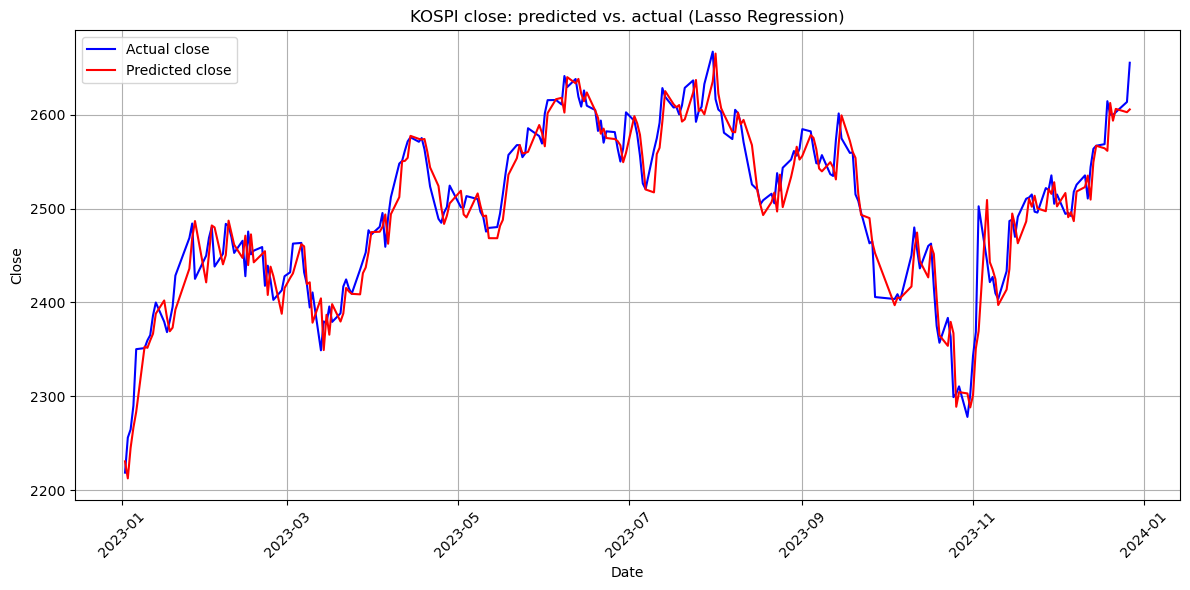

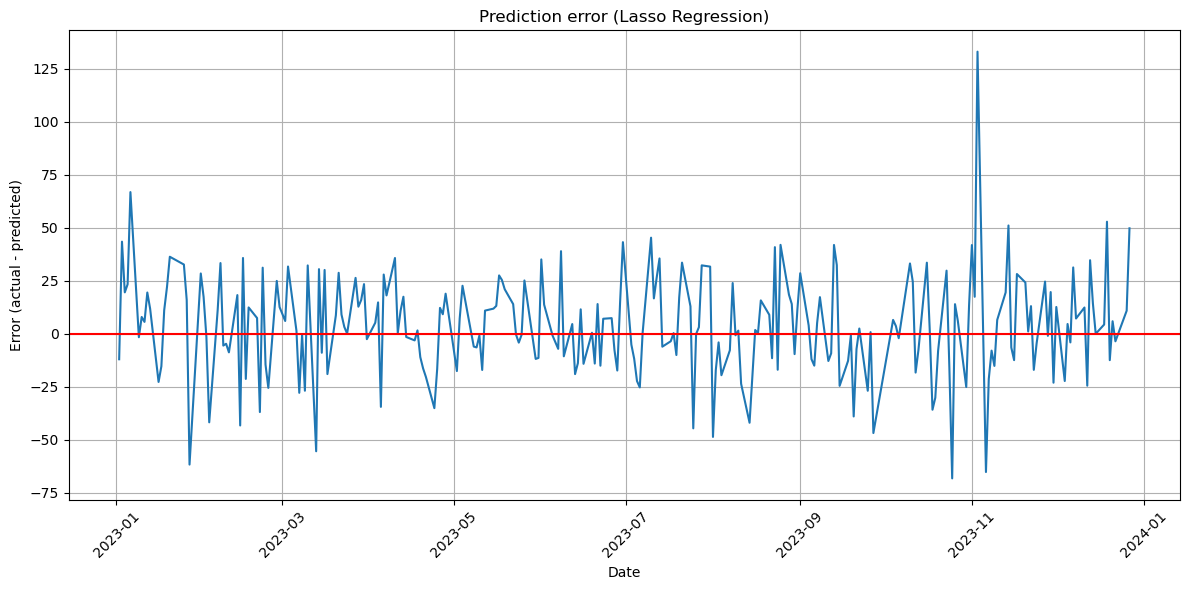


Saved 'Lasso Regression' (selected by CV): 'models/kospi_part2_model.pkl'


In [28]:
# Train and evaluate
results_part2, best_model2 = train_and_evaluate_models(X_train2_scaled, y_train2, X_test2_scaled, y_test2)
best_model2_name, best_model2_estimator = best_model2

# Plots
visualize_predictions(
    test_features2, y_test2, best_model2_estimator, X_test2_scaled, best_model2_name,
    'figures/part2_model_prediction.png', 'figures/part2_prediction_errors.png'
)

# Save the model
joblib.dump(best_model2_estimator, 'models/kospi_part2_model.pkl')
joblib.dump(scaler2, 'models/kospi_part2_scaler.pkl')
print(f"\nSaved '{best_model2_name}' (selected by CV): 'models/kospi_part2_model.pkl'")


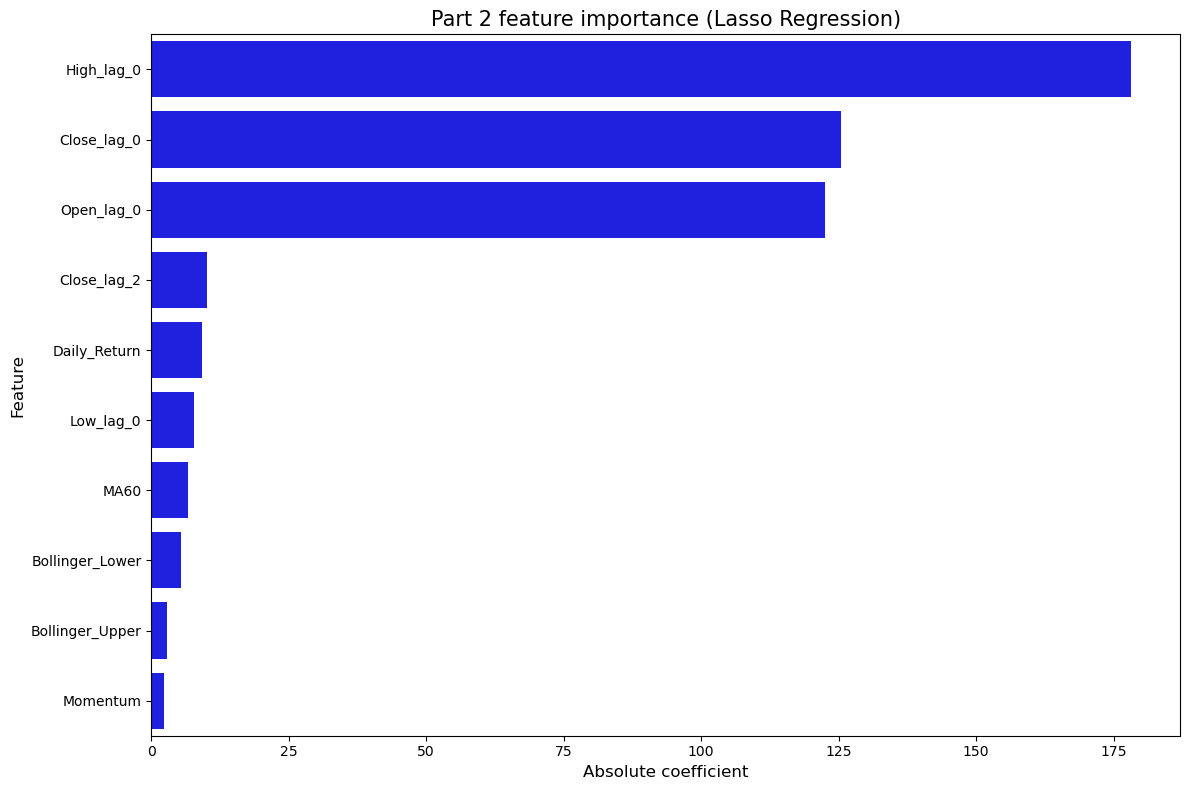


Key feature coefficients:
             Feature  Coefficient
30               RSI      1.31605
34  Bollinger_Middle      0.00000
25               MA5      0.00000


In [29]:
# Feature importance
if hasattr(best_model2_estimator, 'coef_'):  # linear model
    coefficients2 = pd.DataFrame({
        'Feature': X_train2.columns,
        'Coefficient': np.abs(best_model2_estimator.coef_)
    }).sort_values('Coefficient', ascending=False)

    top_features2 = coefficients2.head(10)

    plt.figure(figsize=(12, 8))
    plt.title(f'Part 2 feature importance ({best_model2_name})', fontsize=15)

    highlight_features = ['MA5', 'RSI', 'Bollinger_Middle']
    colors = ['red' if feat in highlight_features else 'blue' for feat in top_features2['Feature']]

    sns.barplot(x='Coefficient', y='Feature', data=top_features2, palette=colors)
    plt.xlabel('Absolute coefficient', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.savefig('figures/part2_feature_importance_highlight.png')
    plt.show()

    print("\nKey feature coefficients:")
    print(coefficients2[coefficients2['Feature'].isin(highlight_features)])
elif hasattr(best_model2_estimator, 'feature_importances_'):  # tree-based model
    feature_importances2 = pd.DataFrame({
        'Feature': X_train2.columns,
        'Importance': best_model2_estimator.feature_importances_
    }).sort_values('Importance', ascending=False).head(10)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importances2)
    plt.title(f'Part 2 feature importance ({best_model2_name})', fontsize=15)
    plt.tight_layout()
    plt.savefig('figures/part2_feature_importance_highlight.png')
    plt.show()

    print("\nFeature importances:")
    print(feature_importances2)


### Part 2 takeaway

Adding technical indicators moves test R² from 0.9209 to 0.9219 (Lasso, CV-selected)
— about +0.001, well within noise. Several indicators are simple functions of the
same close-price history the lags already contain, so they add little new information.


## Part 3. Hyperparameter tuning, ensembling, and robustness checks

### Add day-of-week, MACD, and return-lag features on top of Part 2, tune each model with `RandomizedSearchCV`, and ensemble the best ones.
### Also check how stable performance is over time with walk-forward (expanding-window) validation instead of a single train/test split, and add a residual-based prediction interval.


In [30]:
from src.features import create_extended_features, PART3_EXTRA_FEATURES, prepare_part3_features


In [31]:
print("\n=== Part 3: extended features ===")
X_train3, y_train3, X_test3, y_test3, train_features3, test_features3 = prepare_part3_features(df_train, df_test)

print(f"Number of features: {len(X_train3.columns)}")
print(X_train3.columns.tolist())

# Check that every part uses the same train/test rows (so metrics are directly comparable)
assert X_train.index.equals(X_train2.index) and X_train2.index.equals(X_train3.index)
assert X_test.index.equals(X_test2.index) and X_test2.index.equals(X_test3.index)
print(f"All parts use identical rows: {len(X_train3)} train, {len(X_test3)} test")

X_train3_scaled, X_test3_scaled, scaler3 = scale_features(X_train3, X_test3)



=== Part 3: extended features ===
Number of features: 48
['Open_lag_0', 'High_lag_0', 'Low_lag_0', 'Close_lag_0', 'Volume_lag_0', 'Open_lag_1', 'High_lag_1', 'Low_lag_1', 'Close_lag_1', 'Volume_lag_1', 'Open_lag_2', 'High_lag_2', 'Low_lag_2', 'Close_lag_2', 'Volume_lag_2', 'Open_lag_3', 'High_lag_3', 'Low_lag_3', 'Close_lag_3', 'Volume_lag_3', 'Open_lag_5', 'High_lag_5', 'Low_lag_5', 'Close_lag_5', 'Volume_lag_5', 'MA5', 'MA20', 'MA60', 'Daily_Return', 'Volatility', 'RSI', 'Momentum', 'Consecutive_Up_Days', 'Consecutive_Down_Days', 'Bollinger_Middle', 'Bollinger_Upper', 'Bollinger_Lower', 'EMA12', 'EMA26', 'MACD', 'MACD_Signal', 'DOW_Tue', 'DOW_Wed', 'DOW_Thu', 'DOW_Fri', 'Return_lag_1', 'Return_lag_2', 'Return_lag_3']
All parts use identical rows: 926 train, 243 test


In [32]:
# Hyperparameter search per model with RandomizedSearchCV (TimeSeriesSplit)
from src.models import PART3_SEARCH_SPACE as param_distributions

tscv3 = TimeSeriesSplit(n_splits=5)
tuned_estimators = {}
tuned_cv_mse = {}

for name, (estimator, distributions) in param_distributions.items():
    print(f"\nTuning {name}...")
    search = RandomizedSearchCV(
        estimator, distributions, n_iter=20, cv=tscv3,
        scoring='neg_mean_squared_error', random_state=42, n_jobs=-1
    )
    search.fit(X_train3_scaled, y_train3)
    tuned_estimators[name] = search.best_estimator_
    tuned_cv_mse[name] = -search.best_score_
    print(f"Best parameters: {search.best_params_}")
    print(f"CV MSE: {-search.best_score_:.2f}")



Tuning Ridge Regression...


Best parameters: {'alpha': np.float64(0.0195172246414495)}
CV MSE: 1634.83

Tuning Lasso Regression...


Best parameters: {'alpha': np.float64(0.3470266988650412)}
CV MSE: 1472.03

Tuning Elastic Net...


Best parameters: {'alpha': np.float64(0.0074593432857265485), 'l1_ratio': np.float64(0.9507143064099162)}
CV MSE: 1654.19

Tuning Random Forest...


Best parameters: {'max_depth': 14, 'min_samples_leaf': 9, 'n_estimators': 148}
CV MSE: 46102.26

Tuning Gradient Boosting...


Best parameters: {'learning_rate': np.float64(0.1205712628744377), 'max_depth': 2, 'n_estimators': 120}
CV MSE: 51580.16

Tuning XGBoost...


Best parameters: {'colsample_bytree': np.float64(0.6739417822102108), 'learning_rate': np.float64(0.27051668818999286), 'max_depth': 3, 'n_estimators': 143, 'subsample': np.float64(0.9757995766256756)}
CV MSE: 46959.59


In [33]:
# Evaluate the tuned models on the test set (selection uses CV MSE; the test set is for reporting)
tuned_results = {}
for name, model in tuned_estimators.items():
    y_pred = model.predict(X_test3_scaled)
    tuned_results[name] = {**evaluate_model(y_test3, y_pred, f"{name} (Tuned)"), 'cv_mse': tuned_cv_mse[name]}

best_tuned_name = min(tuned_cv_mse, key=tuned_cv_mse.get)
print(f"\nLowest CV MSE among tuned Part 3 models: {best_tuned_name}")


Ridge Regression (Tuned) performance:
MSE: 603.31
RMSE: 24.56
MAE: 18.72
R^2: 0.9204
Lasso Regression (Tuned) performance:
MSE: 602.52
RMSE: 24.55
MAE: 18.44
R^2: 0.9206
Elastic Net (Tuned) performance:
MSE: 601.31
RMSE: 24.52
MAE: 18.57
R^2: 0.9207
Random Forest (Tuned) performance:
MSE: 641.02
RMSE: 25.32
MAE: 19.76
R^2: 0.9155
Gradient Boosting (Tuned) performance:
MSE: 779.40
RMSE: 27.92
MAE: 21.76
R^2: 0.8972
XGBoost (Tuned) performance:
MSE: 1179.12
RMSE: 34.34
MAE: 26.96
R^2: 0.8445

Lowest CV MSE among tuned Part 3 models: Lasso Regression


In [34]:
# VotingRegressor over the 3 tuned models with the lowest CV MSE
top3_names = sorted(tuned_cv_mse, key=tuned_cv_mse.get)[:3]
print(f"Ensemble members: {top3_names}")

voting_ensemble = VotingRegressor(
    estimators=[(name, clone(tuned_estimators[name])) for name in top3_names]
)
voting_cv = time_series_cv(voting_ensemble, X_train3_scaled, y_train3)
print(f"CV MSE (Voting Ensemble): {voting_cv:.2f}")

voting_ensemble.fit(X_train3_scaled, y_train3)
y_pred_voting = voting_ensemble.predict(X_test3_scaled)
voting_result = {**evaluate_model(y_test3, y_pred_voting, 'Voting Ensemble'), 'cv_mse': voting_cv}

tuned_results['Voting Ensemble'] = voting_result
tuned_estimators['Voting Ensemble'] = voting_ensemble
tuned_cv_mse['Voting Ensemble'] = voting_cv

best_part3_name = min(tuned_cv_mse, key=tuned_cv_mse.get)
best_part3_model = tuned_estimators[best_part3_name]
print(f"\nFinal Part 3 model (lowest CV MSE): {best_part3_name}")


Ensemble members: ['Lasso Regression', 'Ridge Regression', 'Elastic Net']


CV MSE (Voting Ensemble): 1543.77


Voting Ensemble performance:
MSE: 599.63
RMSE: 24.49
MAE: 18.53
R^2: 0.9209

Final Part 3 model (lowest CV MSE): Lasso Regression


In [35]:
# Naive baseline: tomorrow's close = today's close (persistence)
# Next-day price *level* is close to a random walk, so simply copying today's close
# can already give a very high R2. This checks whether our models actually
# beat that simple baseline (evaluated on the same rows as Part 3).
naive_pred = test_features3['Close'].values
naive_true = test_features3['Target'].values
naive_result = evaluate_model(naive_true, naive_pred, 'Naive Persistence (Close_t -> Close_t+1)')


Naive Persistence (Close_t -> Close_t+1) performance:
MSE: 580.18
RMSE: 24.09
MAE: 18.20
R^2: 0.9235


       Part              Model          mse       rmse        mae        r2  \
0  Baseline  Naive Persistence   580.180416  24.086935  18.197654  0.923499   
1    Part 1   Lasso Regression   599.586290  24.486451  18.597956  0.920940   
2    Part 2   Lasso Regression   592.680385  24.345028  18.464054  0.921851   
3    Part 3   Ridge Regression   603.313840  24.562448  18.720743  0.920449   
4    Part 3   Lasso Regression   602.521343  24.546310  18.443201  0.920553   
5    Part 3        Elastic Net   601.305046  24.521522  18.573505  0.920714   
6    Part 3      Random Forest   641.017216  25.318318  19.762468  0.915477   
7    Part 3  Gradient Boosting   779.403458  27.917798  21.757680  0.897230   
8    Part 3            XGBoost  1179.117526  34.338281  26.959820  0.844525   
9    Part 3    Voting Ensemble   599.632330  24.487391  18.532918  0.920934   

         cv_mse  
0           NaN  
1   1199.909730  
2   1441.000993  
3   1634.830157  
4   1472.029398  
5   1654.191133  
6  4

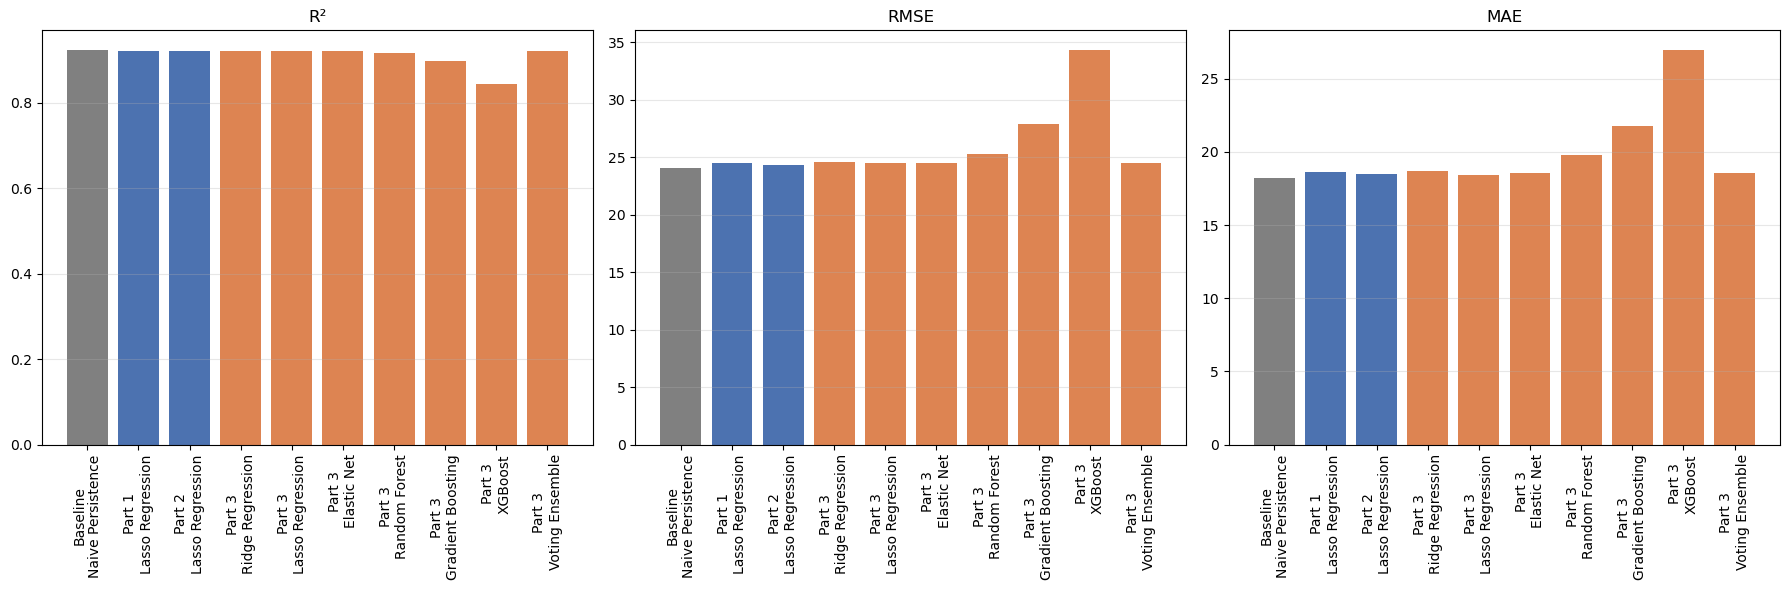

In [36]:
# Compare baseline / Part 1 / Part 2 / Part 3
comparison_rows = []
comparison_rows.append({'Part': 'Baseline', 'Model': 'Naive Persistence', **naive_result})
comparison_rows.append({'Part': 'Part 1', 'Model': best_model_name, **results_part1[best_model_name]})
comparison_rows.append({'Part': 'Part 2', 'Model': best_model2_name, **results_part2[best_model2_name]})
for name, res in tuned_results.items():
    comparison_rows.append({'Part': 'Part 3', 'Model': name, **res})

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df)

n_beating_baseline = (comparison_df.loc[comparison_df['Part'] != 'Baseline', 'rmse'] < naive_result['rmse']).sum()
print(f"\nModels beating the naive baseline (RMSE={naive_result['rmse']:.2f}): {n_beating_baseline} / {len(comparison_df) - 1}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
labels = comparison_df['Part'] + '\n' + comparison_df['Model']
part_colors = {'Baseline': '#808080', 'Part 1': '#4C72B0', 'Part 2': '#4C72B0', 'Part 3': '#DD8452'}
colors = [part_colors[part] for part in comparison_df['Part']]
for ax, metric, title in zip(axes, ['r2', 'rmse', 'mae'], ['R²', 'RMSE', 'MAE']):
    ax.bar(labels, comparison_df[metric], color=colors)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/part3_model_comparison.png')
plt.show()


In [37]:
from src.evaluation import walk_forward_validate


print("\n=== Walk-forward validation (expanding window, final Part 3 model) ===")
walk_forward_model = clone(best_part3_model)
y_pred_wf = walk_forward_validate(walk_forward_model, X_train3_scaled, y_train3, X_test3_scaled, y_test3, step=21)

wf_result = evaluate_model(y_test3, y_pred_wf, f'{best_part3_name} (Walk-forward)')



=== Walk-forward validation (expanding window, final Part 3 model) ===


Lasso Regression (Walk-forward) performance:
MSE: 593.95
RMSE: 24.37
MAE: 18.31
R^2: 0.9217


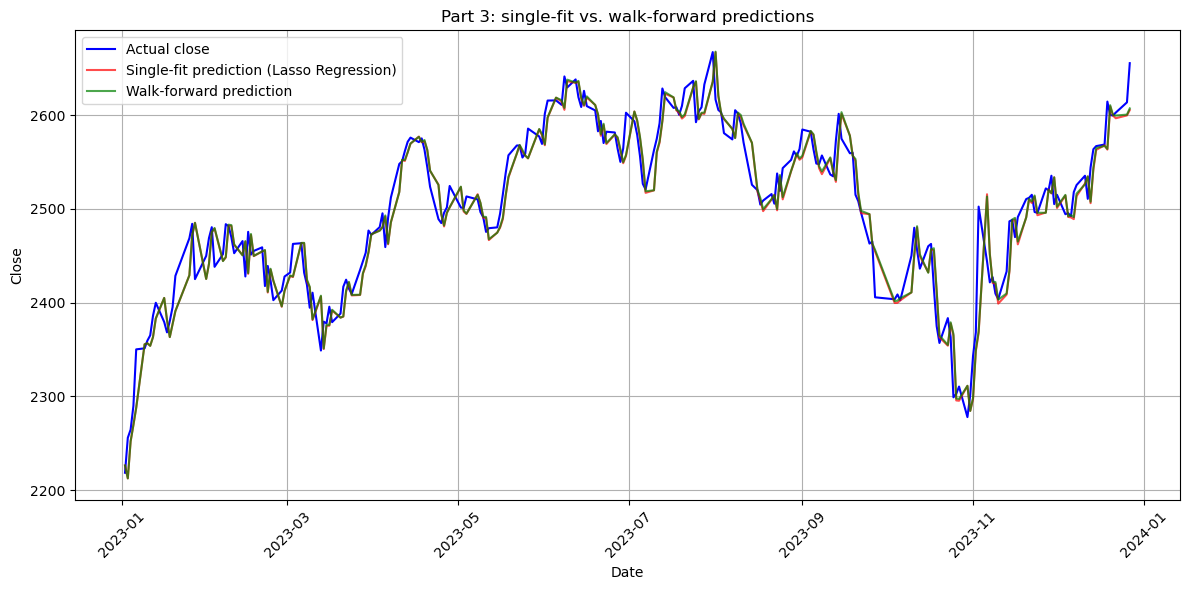

In [38]:
# Walk-forward vs. single-fit predictions
dates3 = test_features3['Date']
y_test3_aligned = y_test3.values
y_pred_wf_aligned = y_pred_wf
y_pred_single_aligned = best_part3_model.predict(X_test3_scaled)

plt.figure(figsize=(12, 6))
plt.plot(dates3, y_test3_aligned, label='Actual close', color='blue')
plt.plot(dates3, y_pred_single_aligned, label=f'Single-fit prediction ({best_part3_name})', color='red', alpha=0.7)
plt.plot(dates3, y_pred_wf_aligned, label='Walk-forward prediction', color='green', alpha=0.7)
plt.title('Part 3: single-fit vs. walk-forward predictions')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/part3_walk_forward_prediction.png')
plt.show()


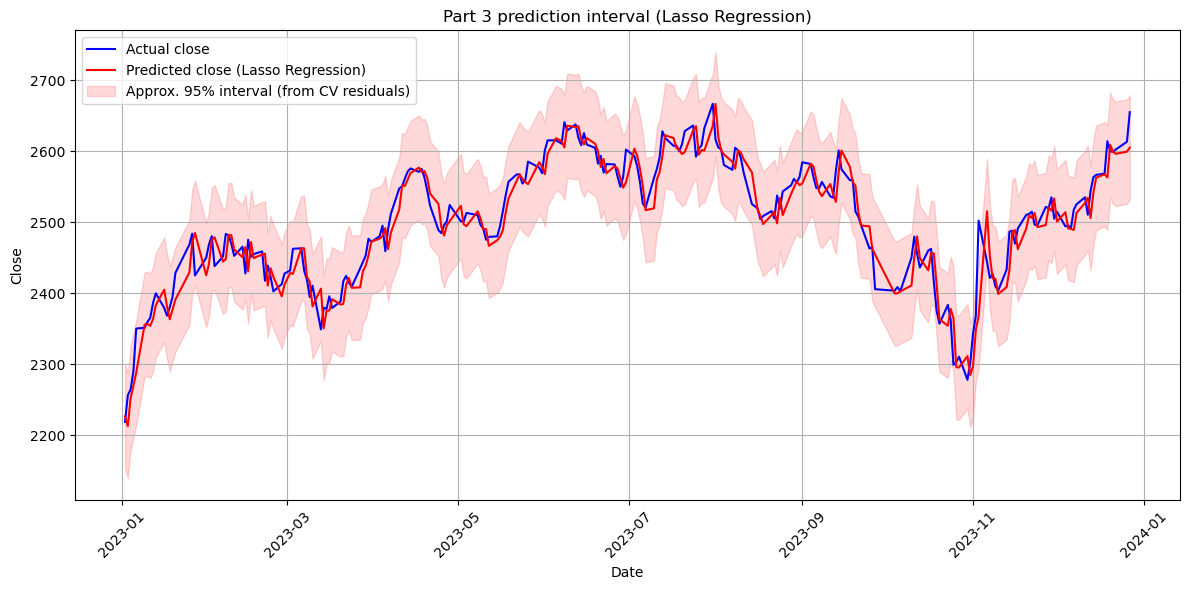

95% interval half-width from CV residuals: ±73.7
Actual test-set coverage (out-of-sample): 99.59%


In [39]:
# Approximate prediction interval: the width comes from out-of-sample TimeSeriesSplit residuals
# on the training data; the test set only measures coverage (sizing it on test residuals would be circular)
from src.evaluation import cv_residuals


cv_res = cv_residuals(best_part3_model, X_train3_scaled, y_train3)
half_width = 1.96 * cv_res.std()

residuals = y_test3_aligned - y_pred_single_aligned   # test residuals (for the diagnostics below)
lower = y_pred_single_aligned - half_width
upper = y_pred_single_aligned + half_width

plt.figure(figsize=(12, 6))
plt.plot(dates3, y_test3_aligned, label='Actual close', color='blue')
plt.plot(dates3, y_pred_single_aligned, label=f'Predicted close ({best_part3_name})', color='red')
plt.fill_between(dates3, lower, upper, color='red', alpha=0.15, label='Approx. 95% interval (from CV residuals)')
plt.title(f'Part 3 prediction interval ({best_part3_name})')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/part3_prediction_interval.png')
plt.show()

coverage = np.mean((y_test3_aligned >= lower) & (y_test3_aligned <= upper))
print(f"95% interval half-width from CV residuals: ±{half_width:.1f}")
print(f"Actual test-set coverage (out-of-sample): {coverage:.2%}")


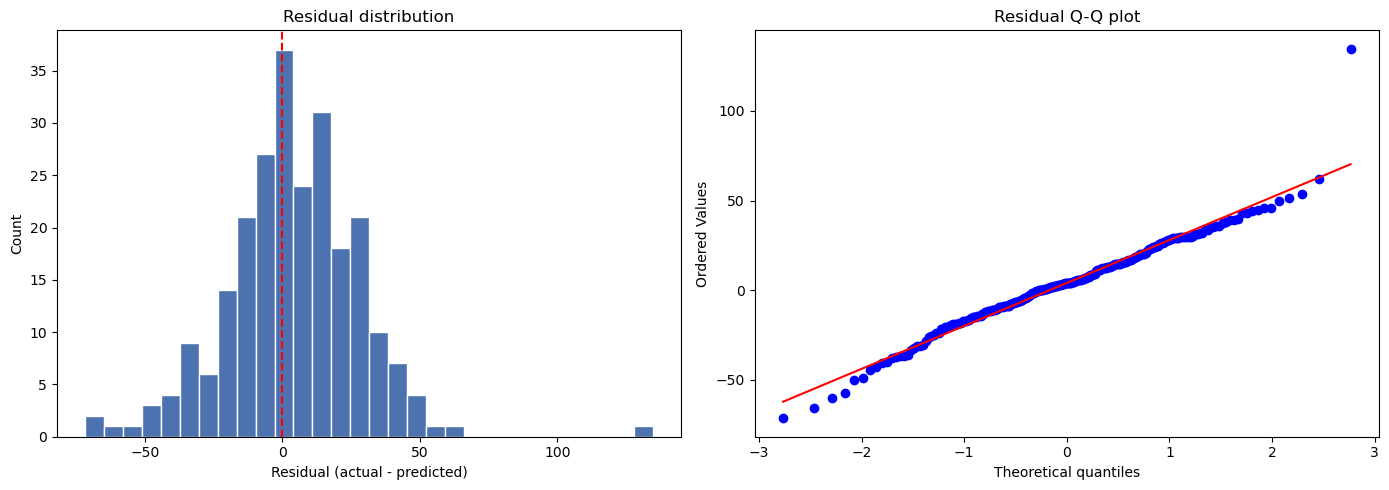

In [40]:
# Residual diagnostics: histogram + Q-Q plot
from scipy import stats as sps

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=30, color='#4C72B0', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residual distribution')
axes[0].set_xlabel('Residual (actual - predicted)')
axes[0].set_ylabel('Count')

sps.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Residual Q-Q plot')

plt.tight_layout()
plt.savefig('figures/part3_residual_diagnostics.png')
plt.show()


In [41]:
# Save the final Part 3 model
joblib.dump(best_part3_model, 'models/kospi_part3_model.pkl')
joblib.dump(scaler3, 'models/kospi_part3_scaler.pkl')
print(f"\nSaved '{best_part3_name}' (selected by CV): 'models/kospi_part3_model.pkl'")

print("\n=== Summary ===")
print(comparison_df.sort_values('r2', ascending=False).to_string(index=False))



Saved 'Lasso Regression' (selected by CV): 'models/kospi_part3_model.pkl'

=== Summary ===
    Part             Model         mse      rmse       mae       r2       cv_mse
Baseline Naive Persistence  580.180416 24.086935 18.197654 0.923499          NaN
  Part 2  Lasso Regression  592.680385 24.345028 18.464054 0.921851  1441.000993
  Part 1  Lasso Regression  599.586290 24.486451 18.597956 0.920940  1199.909730
  Part 3   Voting Ensemble  599.632330 24.487391 18.532918 0.920934  1543.770793
  Part 3       Elastic Net  601.305046 24.521522 18.573505 0.920714  1654.191133
  Part 3  Lasso Regression  602.521343 24.546310 18.443201 0.920553  1472.029398
  Part 3  Ridge Regression  603.313840 24.562448 18.720743 0.920449  1634.830157
  Part 3     Random Forest  641.017216 25.318318 19.762468 0.915477 46102.263165
  Part 3 Gradient Boosting  779.403458 27.917798 21.757680 0.897230 51580.155626
  Part 3           XGBoost 1179.117526 34.338281 26.959820 0.844525 46959.588960


### Part 3 takeaway

Tuning, a `VotingRegressor`, and extra features (EMA/MACD, day-of-week, return lags)
do not help: the tuned Lasso scores R² 0.9206 and the ensemble 0.9209, and none of the
9 compared models beats the naive baseline (RMSE 24.09). Many new features are near-duplicates
of Part 2's (EMA12 vs. MA5 correlation 0.998). Walk-forward validation (R² 0.9217)
agrees with the single split. The 95% interval (±73.7, sized from out-of-sample CV
residuals) covers 99.6% of test points, i.e. it is conservative.

Because the price-level target rewards simply copying today's price, Part 4 changes
the target to the return.


## Part 4. Predict the next-day *return* instead of the price level

### The price level is close to a random walk, so it is hard to beat the naive baseline (tomorrow = today). Switching the target to the next-day return lets feature engineering and tuning be measured meaningfully.
### Only stationary features are used (returns, gaps to moving averages, volatility, volume ratio, ...), and models are compared against zero-forecast and always-up baselines.


In [42]:
from src.features import create_return_features, prepare_part4_features


In [43]:
print("\n=== Part 4: next-day return prediction ===")
X_train4, y_train4, X_test4, y_test4, train_features4, test_features4 = prepare_part4_features(df_train, df_test)

assert X_train4.index.equals(X_train3.index) and X_test4.index.equals(X_test3.index)
print(f"Same rows as Parts 1-3: {len(X_train4)} train, {len(X_test4)} test, {len(PART4_FEATURES)} features")

X_train4_scaled, X_test4_scaled, scaler4 = scale_features(X_train4, X_test4)
y_tr, y_te = y_train4.values, y_test4.values
close_t = test_features4['Close'].values
close_next = close_t * (1 + y_te)

print(f"Share of up days: train {np.mean(y_tr > 0):.3f}, test {np.mean(y_te > 0):.3f}")



=== Part 4: next-day return prediction ===
Same rows as Parts 1-3: 926 train, 243 test, 21 features
Share of up days: train 0.543, test 0.547


In [44]:
from src.evaluation import return_metrics, cv_mse_constant


# Baselines: zero forecast (= naive price baseline), train mean, always up
baseline_rows = {}
zero_pred = np.zeros_like(y_te)
mean_pred = np.full_like(y_te, y_tr.mean())
baseline_rows['Zero (naive price)'] = {**return_metrics(y_te, zero_pred, close_t, close_next),
                                        'cv_mse': cv_mse_constant(y_tr, lambda y: 0.0), 'dir_acc': np.nan}
baseline_rows['Train Mean'] = {**return_metrics(y_te, mean_pred, close_t, close_next),
                               'cv_mse': cv_mse_constant(y_tr, np.mean), 'dir_acc': np.nan}
always_up_acc = np.mean(y_te > 0)   # direction accuracy of always predicting "up"
baseline_rows['Always Up'] = {'rmse': np.nan, 'r2_os': np.nan, 'dir_acc': always_up_acc, 'ic': np.nan,
                              'price_rmse': np.nan, 'cv_mse': np.nan}


In [45]:
# Hyperparameter search with ranges scaled to returns (TimeSeriesSplit, CV MSE)
from src.models import PART4_SEARCH_SPACE as return_search_space

part4_models, part4_rows = {}, {}
for name, (estimator, distributions) in return_search_space.items():
    search = RandomizedSearchCV(estimator, distributions, n_iter=20, cv=TimeSeriesSplit(n_splits=5),
                                scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
    search.fit(X_train4_scaled, y_tr)
    pred = search.best_estimator_.predict(X_test4_scaled)
    part4_models[name] = search.best_estimator_
    part4_rows[name] = {**return_metrics(y_te, pred, close_t, close_next), 'cv_mse': -search.best_score_}
    print(f"{name}: {search.best_params_}")

part4_df = pd.DataFrame({**baseline_rows, **part4_rows}).T[['cv_mse', 'rmse', 'r2_os', 'dir_acc', 'ic', 'price_rmse']]
part4_df['cv_mse'] = part4_df['cv_mse'] * 1e4      # unit: 1e-4
part4_df['rmse'] = part4_df['rmse'] * 100          # unit: %
part4_df = part4_df.rename(columns={'cv_mse': 'cv_mse(1e-4)', 'rmse': 'rmse(%)'})
print("\nTest-set results (return prediction)")
print(part4_df.to_string(float_format=lambda v: f"{v:.4f}"))

best_part4_name = min(part4_models, key=lambda n: part4_rows[n]['cv_mse'])
best_part4_model = part4_models[best_part4_name]
zero_cv = baseline_rows['Zero (naive price)']['cv_mse']
print(f"\nLowest CV MSE model: {best_part4_name} (vs. zero-forecast CV MSE {zero_cv:.6f}: "
      f"{part4_rows[best_part4_name]['cv_mse'] / zero_cv - 1:+.2%})")


Ridge: {'alpha': np.float64(457.0563099801454)}


Lasso: {'alpha': np.float64(0.0008471801418819979)}


Elastic Net: {'alpha': np.float64(0.007286653737491046), 'l1_ratio': np.float64(0.7775576133048151)}


Random Forest: {'max_depth': 2, 'min_samples_leaf': 30, 'n_estimators': 202}


Gradient Boosting: {'learning_rate': np.float64(0.008203274596050749), 'max_depth': 1, 'n_estimators': 120, 'subsample': np.float64(0.7117007403531848)}


XGBoost: {'colsample_bytree': np.float64(0.7159725093210578), 'learning_rate': np.float64(0.011963764382790322), 'max_depth': 3, 'n_estimators': 64, 'subsample': np.float64(0.728034992108518)}

Test-set results (return prediction)
                    cv_mse(1e-4)  rmse(%)   r2_os  dir_acc      ic  price_rmse
Zero (naive price)        1.8286   0.9793  0.0000      NaN     NaN     24.0869
Train Mean                1.8354   0.9785  0.0017      NaN     NaN     24.0695
Always Up                    NaN      NaN     NaN   0.5473     NaN         NaN
Ridge                     1.8213   0.9942 -0.0305   0.5103  0.0188     24.4678
Lasso                     1.8323   0.9833 -0.0080   0.4979  0.0093     24.1964
Elastic Net               1.8354   0.9785  0.0017   0.5473     NaN     24.0695
Random Forest             1.8382   0.9909 -0.0237   0.5226 -0.0332     24.3675
Gradient Boosting         1.8373   0.9791  0.0004   0.5473     NaN     24.0826
XGBoost                   1.8309   0.9832 -0.0080   0.5226

In [46]:
# Significance test: is direction accuracy higher than the "always up" baseline? (one-sided binomial test)
n_test = len(y_te)
print(f"'Always up' direction accuracy: {always_up_acc:.3f}  (n={n_test}, std. error about {np.sqrt(0.25 / n_test):.3f})")
for name, row in part4_rows.items():
    k = int(round(row['dir_acc'] * n_test))
    p = st.binomtest(k, n_test, p=always_up_acc, alternative='greater').pvalue
    print(f"{name:18s} direction accuracy {row['dir_acc']:.3f}  vs always-up p-value={p:.3f}  IC={row['ic']:+.3f}")

best_row = part4_rows[best_part4_name]
print(f"\n[Selected by CV] {best_part4_name}: OOS R² vs. zero forecast = {best_row['r2_os']:+.4f}, "
      f"price RMSE {best_row['price_rmse']:.2f} vs. naive {baseline_rows['Zero (naive price)']['price_rmse']:.2f}")


'Always up' direction accuracy: 0.547  (n=243, std. error about 0.032)
Ridge              direction accuracy 0.510  vs always-up p-value=0.889  IC=+0.019
Lasso              direction accuracy 0.498  vs always-up p-value=0.946  IC=+0.009
Elastic Net        direction accuracy 0.547  vs always-up p-value=0.526  IC=+nan
Random Forest      direction accuracy 0.523  vs always-up p-value=0.799  IC=-0.033
Gradient Boosting  direction accuracy 0.547  vs always-up p-value=0.526  IC=+nan
XGBoost            direction accuracy 0.523  vs always-up p-value=0.799  IC=-0.037

[Selected by CV] Ridge: OOS R² vs. zero forecast = -0.0305, price RMSE 24.47 vs. naive 24.09


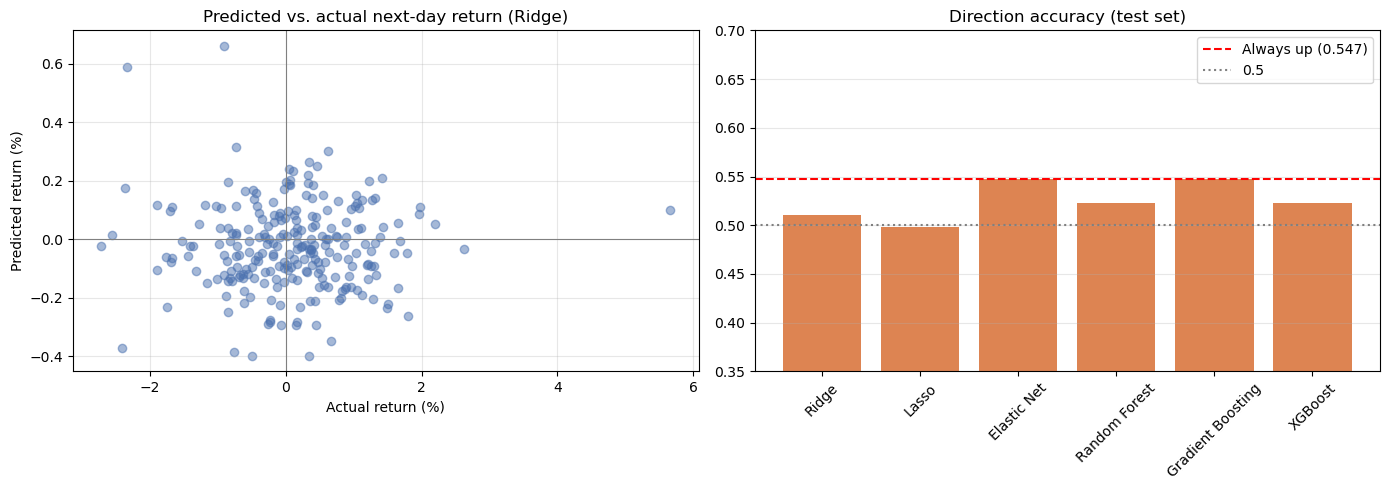


Saved 'Ridge' (selected by CV): 'models/kospi_part4_model.pkl'


In [47]:
# Plots: predicted vs. actual return, direction accuracy
best_pred4 = best_part4_model.predict(X_test4_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_te * 100, best_pred4 * 100, alpha=0.5, color='#4C72B0')
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].axvline(0, color='gray', linewidth=0.8)
axes[0].set_title(f'Predicted vs. actual next-day return ({best_part4_name})')
axes[0].set_xlabel('Actual return (%)')
axes[0].set_ylabel('Predicted return (%)')
axes[0].grid(True, alpha=0.3)

names = list(part4_rows)
accs = [part4_rows[n]['dir_acc'] for n in names]
axes[1].bar(names, accs, color='#DD8452')
axes[1].axhline(always_up_acc, color='red', linestyle='--', label=f"Always up ({always_up_acc:.3f})")
axes[1].axhline(0.5, color='gray', linestyle=':', label='0.5')
axes[1].set_ylim(0.35, 0.7)
axes[1].set_title('Direction accuracy (test set)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/part4_return_prediction.png')
plt.show()

joblib.dump(best_part4_model, 'models/kospi_part4_model.pkl')
joblib.dump(scaler4, 'models/kospi_part4_scaler.pkl')
print(f"\nSaved '{best_part4_name}' (selected by CV): 'models/kospi_part4_model.pkl'")


### Part 4 takeaway

Predicting the next-day return removes the random-walk shortcut, and no model shows
skill: none beats a zero or mean forecast (the CV-selected Ridge has OOS R² −0.031),
none beats "always up" on direction (all binomial p ≥ 0.5), and the best rank
correlation is +0.019. With 243 test points a small real edge could not be detected,
but nothing here suggests one.

**Overall.** Daily price and volume features carry no detectable signal for next-day
KOSPI moves beyond "tomorrow ≈ today". The value of this project is the method:
matched information sets, selection without test leakage, and baselines that keep
a flattering R² honest.
